In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
!pip install umap-learn --quiet
from umap import UMAP
import lightgbm as lgb
import torch

In [8]:
DATA_DIR = "/kaggle/input/keypoints/test"
LABEL_CSV = "/kaggle/input/label-w-name/cleaned_labels_with_filename (1).csv"

In [9]:
label_df = pd.read_csv(LABEL_CSV)
label_df['label'] = label_df['PD_or_C'].apply(lambda x: 1 if x == 'PD' else 0)

In [10]:
def extract_features(keypoints):
    # Keypoints: (frames, 34)
    if keypoints.shape[0] < 2:
        return np.zeros(34)  # fallback
    velocity = np.diff(keypoints, axis=0)
    return np.concatenate([
        velocity.mean(axis=0),
        velocity.std(axis=0)
    ])

In [11]:
import os
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

# Load label file
label_df = pd.read_csv(LABEL_CSV)
label_df['label'] = label_df['PD_or_C'].map({'C': 0, 'PD': 1})  # Convert to binary labels

KEYPOINT_DIR = '/kaggle/input/keypoints/test/'

features, labels, valid_filenames = [], [], []

for i, row in tqdm(label_df.iterrows(), total=len(label_df)):
    fname = row['filename'] + ".csv"
    label = row['label']
    path = os.path.join(KEYPOINT_DIR, fname)
    if not os.path.exists(path):
        continue
    try:
        keypoints = np.loadtxt(path, delimiter=',')
        if keypoints.shape[1] != 34:
            continue
        feature_vector = extract_features(keypoints)
        features.append(feature_vector)
        labels.append(label)
        valid_filenames.append(fname)
    except:
        continue

X = np.array(features)
y = np.array(labels)

print("✅ Extracted features:", X.shape)
print("✅ Labels:", y.shape)

  0%|          | 0/1708 [00:00<?, ?it/s]

✅ Extracted features: (1700, 68)
✅ Labels: (1700,)


In [12]:
print(label_df.columns)

Index(['Turn ID', 'Participant ID number', 'PD_or_C',
       'number_of_turning_steps', 'turning_angle', 'type_of_turn',
       'turning_duration', 'On_or_Off_medication', 'filename', 'label'],
      dtype='object')


In [13]:
label_df['label'] = label_df['PD_or_C'].map({'C': 0, 'PD': 1})

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


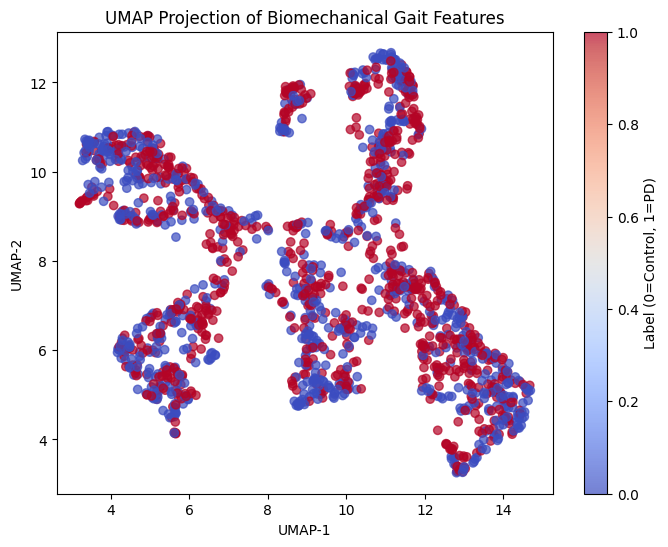

In [14]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import umap

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_umap = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title("UMAP Projection of Biomechanical Gait Features")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(label='Label (0=Control, 1=PD)')
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Train classifier
clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.59      0.67       154
           1       0.72      0.86      0.78       186

    accuracy                           0.74       340
   macro avg       0.75      0.73      0.73       340
weighted avg       0.74      0.74      0.73       340



In [16]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier 
from sklearn.metrics import classification_report, confusion_matrix

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Train classifier
clf = XGBClassifier(n_estimators=200, max_depth=10, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.64      0.67       154
           1       0.72      0.77      0.74       186

    accuracy                           0.71       340
   macro avg       0.71      0.71      0.71       340
weighted avg       0.71      0.71      0.71       340



In [25]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
features, labels = [], []

for i, row in tqdm(label_df.iterrows(), total=len(label_df)):
    fname = row['filename'] + ".csv"
    label = row['PD_or_C']  # or whatever your label column is
    path = os.path.join(KEYPOINT_DIR, fname)
    
    if not os.path.exists(path):
        continue
    try:
        kp = np.loadtxt(path, delimiter=',')
        if kp.shape[1] != 34:
            continue
        features.append(kp)     # unpadded sequence
        labels.append(label)
    except:
        continue

# Encode labels
le = LabelEncoder()
y = le.fit_transform(labels)  # y = 0 for Control, 1 for PD

# Pad sequences
X_seq = pad_sequences(features, maxlen=200, dtype='float32', padding='post', truncating='post')

  0%|          | 0/1708 [00:00<?, ?it/s]

In [26]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization

# Encode labels
le = LabelEncoder()
y = le.fit_transform(labels)

# Pad keypoint sequences
X_seq = pad_sequences(features, maxlen=200, dtype='float32', padding='post', truncating='post')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_seq, y, test_size=0.2, stratify=y, random_state=42)

# Model
model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_seq.shape[1], X_seq.shape[2])),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    LSTM(64, return_sequences=False),
    Dropout(0.5),

    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary output
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 198, 64)             │           6,592 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 198, 64)             │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 99, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 97, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 97, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 48, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 85,697 (334.75 KB)

 Trainable params: 85,313 (333.25 KB)

 Non-trainable params: 384 (1.50 KB)

In [27]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
    ],
    verbose=1
)

Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.5179 - loss: 0.7067 - val_accuracy: 0.5221 - val_loss: 0.6918
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.5348 - loss: 0.7076 - val_accuracy: 0.4926 - val_loss: 0.6891
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.4968 - loss: 0.6975 - val_accuracy: 0.5294 - val_loss: 0.6839
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5550 - loss: 0.6868 - val_accuracy: 0.5294 - val_loss: 0.6820
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.5029 - loss: 0.6983 - val_accuracy: 0.5294 - val_loss: 0.6843
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.5393 - loss: 0.6841 - val_accuracy: 0.5294 - val_loss: 0.6824
Epoch 7/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.5410 - loss: 0.6859 - val_accuracy: 0.5294 - val_loss: 0.6793
Epoch 8/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.5251 - loss: 0.6897 - val_accuracy: 0.5294 - v

In [28]:
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
              precision    recall  f1-score   support

           0       0.59      0.16      0.25       154
           1       0.57      0.91      0.70       186

    accuracy                           0.57       340
   macro avg       0.58      0.53      0.47       340
weighted avg       0.57      0.57      0.49       340

[[ 24 130]
 [ 17 169]]


In [29]:
# import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# === Paths ===
LABEL_CSV = "/kaggle/input/label-w-name/cleaned_labels_with_filename (1).csv"
KEYPOINT_DIR = "/kaggle/input/keypoints/test/"

# === Load label data ===
label_df = pd.read_csv(LABEL_CSV)
label_df = label_df[label_df['filename'].notnull()]
label_df['PD_or_C'] = label_df['PD_or_C'].map({'PD': 1, 'C': 0})
y = label_df['PD_or_C'].values

In [30]:
# === Feature extraction function ===
def extract_features(keypoints_sequence):
    keypoints_sequence = np.array(keypoints_sequence).reshape(-1, 17, 2)
    left_foot = keypoints_sequence[:, 15, :]
    right_foot = keypoints_sequence[:, 16, :]
    step_length = np.linalg.norm(left_foot - right_foot, axis=1).mean()
    stride_variability = np.std(np.linalg.norm(left_foot - right_foot, axis=1))
    head = keypoints_sequence[:, 0, :]
    orientation_changes = np.diff(np.arctan2(head[:, 1], head[:, 0]))
    turning_speed = np.mean(np.abs(orientation_changes))
    center_of_mass = (left_foot + right_foot) / 2
    sway_x, sway_y = np.std(center_of_mass, axis=0)
    foot_movement = np.linalg.norm(np.diff(left_foot, axis=0), axis=1)
    step_duration = (foot_movement > 0.1).sum()
    velocity = np.diff(center_of_mass, axis=0)
    acceleration = np.diff(velocity, axis=0)
    jerk = np.mean(np.abs(acceleration))
    left_hip = keypoints_sequence[:, 11, :]
    right_hip = keypoints_sequence[:, 12, :]
    left_knee = keypoints_sequence[:, 13, :]
    right_knee = keypoints_sequence[:, 14, :]
    hip_symmetry = np.mean(np.abs(left_hip - right_hip))
    knee_symmetry = np.mean(np.abs(left_knee - right_knee))
    return [
        step_length, stride_variability, turning_speed,
        sway_x, sway_y, step_duration, jerk,
        hip_symmetry, knee_symmetry
    ]

In [31]:
# === Process each sample ===
biomech_features = []
sequence_means = []
valid_labels = []

for _, row in tqdm(label_df.iterrows(), total=len(label_df)):
    fname = row['filename']
    path = os.path.join(KEYPOINT_DIR, fname + ".csv")
    if not os.path.exists(path):
        continue
    try:
        keypoints = np.loadtxt(path, delimiter=',')
        if keypoints.shape[1] != 34:
            continue
        keypoints_seq = keypoints.reshape(-1, 17, 2)
        biomech = extract_features(keypoints)
        seq_mean = keypoints_seq.mean(axis=0).flatten()  # (34,)
        biomech_features.append(biomech)
        sequence_means.append(seq_mean)
        valid_labels.append(row['PD_or_C'])
    except:
        continue

100%|██████████| 1708/1708 [00:04<00:00, 368.54it/s]


[RF] Train Accuracy: 0.9971
[RF] Val Accuracy: 0.7147


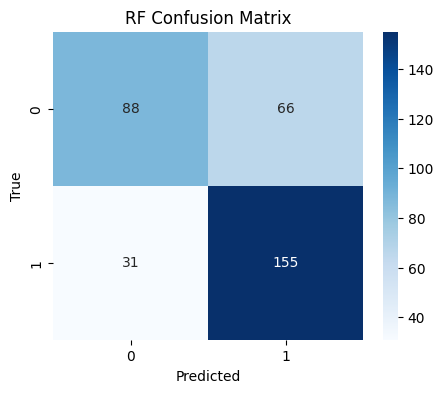

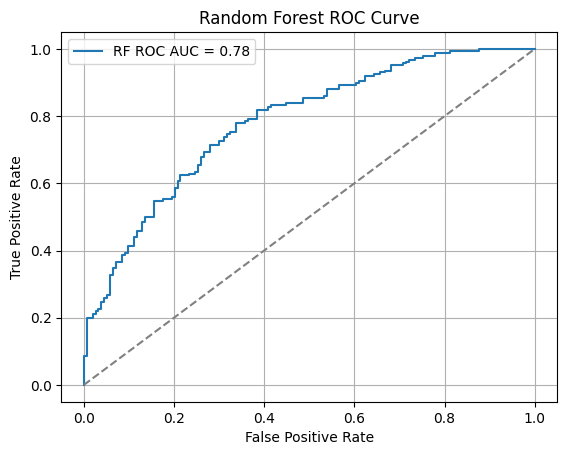

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.57      0.64       154
           1       0.70      0.83      0.76       186

    accuracy                           0.71       340
   macro avg       0.72      0.70      0.70       340
weighted avg       0.72      0.71      0.71       340



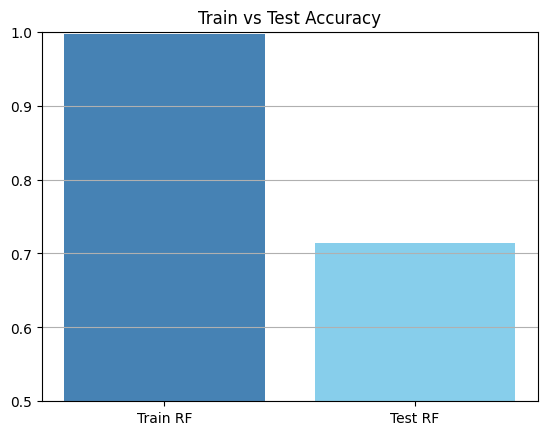

In [35]:
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Train accuracy
train_acc_rf = accuracy_score(y_train, clf.predict(X_train))
# Validation accuracy
val_acc_rf = accuracy_score(y_test, y_pred)

print(f"[RF] Train Accuracy: {train_acc_rf:.4f}")
print(f"[RF] Val Accuracy: {val_acc_rf:.4f}")

#Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues")
plt.title("RF Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

#ROC Curve
y_prob_rf = clf.predict_proba(X_test)[:, 1]  # probabilities for class 1
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure()
plt.plot(fpr_rf, tpr_rf, label=f"RF ROC AUC = {auc_rf:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.grid()
plt.show()

#Classification Report
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))

#Accuracy Comparison
plt.figure()
plt.bar(['Train RF', 'Test RF'], [train_acc_rf, val_acc_rf], color=['steelblue', 'skyblue'])
plt.title("Train vs Test Accuracy")
plt.ylim(0.5, 1.0)
plt.grid(axis='y')
plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


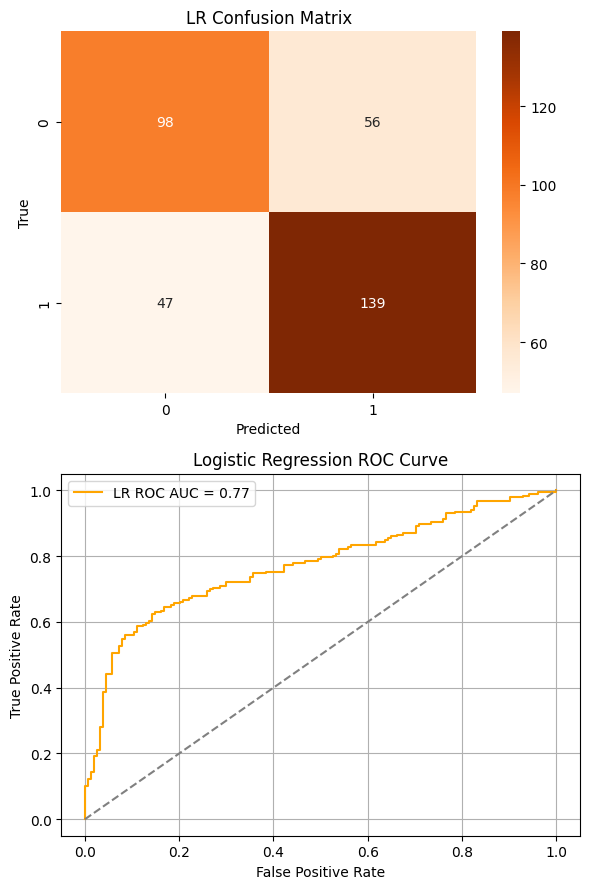

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

# Plotting
fig, axs = plt.subplots(2, 1, figsize=(6, 9))

# 📊 Confusion Matrix
sns.heatmap(cm_lr, annot=True, fmt='d', cmap="Oranges", ax=axs[0])
axs[0].set_title("LR Confusion Matrix")
axs[0].set_xlabel("Predicted")
axs[0].set_ylabel("True")

# 📈 ROC Curve
axs[1].plot(fpr_lr, tpr_lr, label=f"LR ROC AUC = {auc_lr:.2f}", color='orange')
axs[1].plot([0, 1], [0, 1], linestyle="--", color='gray')
axs[1].set_xlabel("False Positive Rate")
axs[1].set_ylabel("True Positive Rate")
axs[1].set_title("Logistic Regression ROC Curve")
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [51]:
print(label_df.columns)

Index(['Turn ID', 'Participant ID number', 'PD_or_C',
       'number_of_turning_steps', 'turning_angle', 'type_of_turn',
       'turning_duration', 'On_or_Off_medication', 'filename'],
      dtype='object')


In [55]:
import pandas as pd
import os
import numpy as np
from tqdm import tqdm

def extract_features(keypoints_sequence):
    keypoints_sequence = np.array(keypoints_sequence).reshape(-1, 17, 2)

    left_foot = keypoints_sequence[:, 15, :]
    right_foot = keypoints_sequence[:, 16, :]
    step_length = np.linalg.norm(left_foot - right_foot, axis=1).mean()
    stride_variability = np.std(np.linalg.norm(left_foot - right_foot, axis=1))

    head = keypoints_sequence[:, 0, :]
    orientation_changes = np.diff(np.arctan2(head[:, 1], head[:, 0]))
    turning_speed = np.mean(np.abs(orientation_changes))

    center_of_mass = (left_foot + right_foot) / 2
    sway_x, sway_y = np.std(center_of_mass, axis=0)

    foot_movement = np.linalg.norm(np.diff(left_foot, axis=0), axis=1)
    step_duration = (foot_movement > 0.1).sum()

    velocity = np.diff(center_of_mass, axis=0)
    acceleration = np.diff(velocity, axis=0)
    jerk = np.mean(np.abs(acceleration))

    left_hip = keypoints_sequence[:, 11, :]
    right_hip = keypoints_sequence[:, 12, :]
    left_knee = keypoints_sequence[:, 13, :]
    right_knee = keypoints_sequence[:, 14, :]

    hip_symmetry = np.mean(np.abs(left_hip - right_hip))
    knee_symmetry = np.mean(np.abs(left_knee - right_knee))

    return [
        step_length, stride_variability, turning_speed,
        sway_x, sway_y, step_duration, jerk, hip_symmetry, knee_symmetry
    ]

# Load label file
label_df = pd.read_csv("/kaggle/input/label-w-name/cleaned_labels_with_filename (1).csv")
keypoints_dir = "/kaggle/input/keypoints/test/"

features = []
labels = []

# Loop and collect valid samples only
for i, row in tqdm(label_df.iterrows(), total=len(label_df)):
    fname = row['filename'] + ".csv"
    fpath = os.path.join(keypoints_dir, fname)
    
    if not os.path.exists(fpath):
        continue  # Skip if file doesn't exist

    try:
        keypoints = pd.read_csv(fpath).values
        feat = extract_features(keypoints)
        features.append(feat)
        labels.append(row['PD_or_C'])  # Correct label column
    except Exception as e:
        print(f"Failed on {fname}: {e}")
        continue

X = np.array(features)
y = np.array(labels)

print("Final shapes ->", X.shape, y.shape)

100%|██████████| 1708/1708 [00:08<00:00, 207.47it/s]

Final shapes -> (1700, 9) (1700,)
